In [95]:
import os
import sys
# src_path = os.path.realpath(os.path.join(os.path.dirname(__file__), '../../src'))
# sys.path.append(src_path)
src_path = os.path.realpath(os.path.join(os.getcwd(), './src'))
sys.path.append(src_path)

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
import random
from utilFuncs import *
import matplotlib.patches as mpatches
import matplotlib.lines as mlines



In [96]:
n_design_vars = 7
unit_cell_name = 'C12'
n_data_files = 2 # seed 0-1 (2), just seed0 (1)
# make sure analysis is done on the same geometry and compression ratio 
lattice_height_mm = 12.7 # mm
compression_pct = 40
reduce_data = False # reduce data to 1000 for testing NN, RBF, GPR, default false
include_partial = True # include partial data for training, default true


In [97]:
save_dir = unit_cell_name + 'NN' + str(n_design_vars) + 'var/'
filenames = [] # Initialize an empty list to store the generated filenames

for seed_num in range(n_data_files): # range(2) will generate 0, 1
    filename = (save_dir + 'abaqusComp' + str(compression_pct) +
                unit_cell_name + 'LHS_' + str(n_design_vars) + 'var_seedNum' + str(seed_num)+ '_0_2500')
    filenames.append(filename)

if n_design_vars == 2: # uniform data replace filenames
    filenames = [save_dir + 'abaqusComp' + str(compression_pct) + unit_cell_name + 'uniform_' + str(n_design_vars) + 'var_seedNum0_0_2500']

compression_pct = 40
compression_ratio = compression_pct * 0.01
max_disp_uz_mm = lattice_height_mm * compression_ratio # mm

file_ext = ".txt"
design_vars = np.array([])
disp_mm = np.array([])
forces = np.array([])
sim_status = np.array([])

for filename in filenames:
    filename = filename + file_ext
    
    dv_batch, disp_batch, force_batch, status_batch = extract_ABQ_values(filename, torch.linspace(0, 1, 11) * max_disp_uz_mm)
    
    if design_vars.size == 0:
        design_vars = dv_batch
        disp_mm = disp_batch
        forces = force_batch
        sim_status = status_batch
    else:
        design_vars = np.concatenate((design_vars, dv_batch))
        disp_mm = np.concatenate((disp_mm, disp_batch))
        forces = np.concatenate((forces, force_batch))
        sim_status = np.concatenate((sim_status, status_batch))
# if any values in disp_mm and forces are nan, make them 0.0
disp_mm = np.nan_to_num(disp_mm, nan=0.0)
forces = np.nan_to_num(forces, nan=0.0)

disp_norm = disp_mm / max_disp_uz_mm # assuming at least one simulation reached max_disp_uz_mm, normalize by max_disp_uz_mm

disp_checkpoints = np.linspace(0, 1, 11)

valid_step_mask = ((np.abs(disp_norm - disp_checkpoints[np.newaxis, :])) <= 1e-6) * 1.0

sim_status = 1.0 * (valid_step_mask[:, 1::].sum(axis=1) == 10.0) # fix sim_status to be 0 or 1

design_vars_converged = design_vars.copy()[sim_status == 1.0, :]
forces_converged = forces.copy()[sim_status == 1.0, :]

if reduce_data:
    # randomly select 1000 data points for design_vars disp_norm forces and sim_status
    num_data_points = disp_norm.shape[0]
    num_samples = min(1004, num_data_points)
    random.seed(1)
    random_indices = random.sample(range(num_data_points), num_samples)
    design_vars = design_vars[random_indices, :]
    disp_norm = disp_norm[random_indices, :]
    forces = forces[random_indices, :]
    sim_status = sim_status[random_indices]
    valid_step_mask = valid_step_mask[random_indices, :]

# take out the failed or keep solutions
mask_diverged = valid_step_mask[sim_status == 0, :]

if include_partial:
    mask_input = valid_step_mask[sim_status <= 1, :]
    disp_input = disp_norm[sim_status <= 1, :]
    model_inputs = design_vars[sim_status <= 1, :]
    model_targets = forces[sim_status <= 1, :]
    design_vars = design_vars[sim_status <= 1, :]
else:
    mask_input = valid_step_mask[sim_status == 1, :]
    disp_input = disp_norm[sim_status == 1, :]
    model_inputs = design_vars[sim_status == 1, :]
    model_targets = forces[sim_status == 1, :]
    design_vars = design_vars[sim_status == 1, :]

model_targets = model_targets * mask_input

# inputs_diverged = design_vars[sim_status == 0, :]
# outputs_diverged = forces[sim_status == 0, :]

input_dim = model_inputs.shape[1]
output_dim = model_targets.shape[1]

all_inputs = np.concatenate((model_inputs, mask_input), axis=1)
all_targets = model_targets.copy()

min_success_ratio = 1/11
# make sure the partial curve has at least half of the data
n_valid_steps = np.sum(mask_input[:, 1::], axis=1) # skip the first 0th size
sim_status = n_valid_steps / (np.max(n_valid_steps)) # change sim_status to show > half success
sufficient_data_mask = (sim_status >= min_success_ratio)

## remove the less than half success 
model_inputs = np.concatenate((model_inputs, mask_input), axis=1)[sufficient_data_mask, :]
model_targets = model_targets[sufficient_data_mask, :]
# inputs_diverged = np.concatenate((inputs_diverged, mask_diverged), axis=1)

success = np.sum(sim_status == 1)
partial = np.sum((sim_status >= min_success_ratio) & (sim_status < 1))
failure = np.sum(sim_status < min_success_ratio)
print(f"Data shapes: Input (with mask) {model_inputs.shape}, Output {model_targets.shape}")
print(f"Classification counts: Success={success}, Partial={partial}, Failure={failure}")

Data shapes: Input (with mask) (4967, 18), Output (4967, 11)
Classification counts: Success=2553, Partial=2414, Failure=33


In [98]:
# # make some force range, and use only that data
# mean_force_per_sample = np.mean(model_targets, axis=1)

# force_min, force_max = -np.max(mean_force_per_sample), (np.max(mean_force_per_sample) + 1.0)

# if force_max > 0:
#     model_inputs = model_inputs[(mean_force_per_sample >= force_min) & (mean_force_per_sample <= force_max), :]
#     model_targets = model_targets[(mean_force_per_sample >= force_min) & (mean_force_per_sample <= force_max), :]

In [99]:
# split the data into train and test sets

# when using two points to prove the method, use train_ratio=0.9999, else use train_ratio=0.8, 
# so that all the data goes to training (success only for RBF, GPR, NNs, and success+partial for NNsp), 
# validation data is handled seperately by the two points, and test data is handled by the two points as well.
if reduce_data:
    train_ratio = 0.999 # 0.8 or 0.9999
else:
    train_ratio = 0.8
n_samples = int(model_inputs.shape[0] / 1)  # Get the number of samples (rows)
n_train = int(n_samples * train_ratio)  # Calculate number of training samples

random.seed(0) 
# Generate random indices for shuffling
indices = list(range(n_samples))
random.shuffle(indices)

# Split indices into training and testing
train_indices = indices[:n_train]
test_indices = indices[n_train:]

# Use the shuffled indices to select data
train_inputs_raw = model_inputs[train_indices, :]
train_displacements = disp_input[train_indices, :]
train_targets_raw = model_targets[train_indices, :]

test_inputs_raw = model_inputs[test_indices, :]
test_displacements = disp_input[test_indices, :]
test_targets_raw = model_targets[test_indices, :]

print('#######################')
train_step_mask = train_inputs_raw[:, -mask_input.shape[1]:].copy() # extract the mask part of the input
n_train_rows = train_step_mask.shape[0]
n_valid_steps = np.sum(train_step_mask[:, 1::], axis=1) # skip the first 0th size
train_success_ratio = n_valid_steps / (np.max(n_valid_steps)) # change to show > half success
min_success_ratio = 1/11
success = np.sum(train_success_ratio == 1)
partial = np.sum((train_success_ratio >= min_success_ratio) & (train_success_ratio < 1))
failure = np.sum(train_success_ratio < min_success_ratio)
print(f"Classification counts on train data: Success={success}, Partial={partial}, Failure={failure}")

print('#######################')
test_step_mask = test_inputs_raw[:, -mask_input.shape[1]:].copy() # extract the mask part of the input
n_test_rows = test_step_mask.shape[0]
n_valid_steps = np.sum(test_step_mask[:, 1::], axis=1) # skip the first 0th size
test_success_ratio = n_valid_steps / (np.max(n_valid_steps)) # change to show > half success
min_success_ratio = 1/11
success = np.sum(test_success_ratio == 1)
partial = np.sum((test_success_ratio >= min_success_ratio) & (test_success_ratio < 1))
failure = np.sum(test_success_ratio < min_success_ratio)
print(f"Classification counts on test data: Success={success}, Partial={partial}, Failure={failure}")
print('#######################')

# for removing the data with specific radius, 
# can be used to make sure train and test have different data points, 
if n_design_vars == 2:
    train_inputs_raw[:, train_inputs_raw.shape[1] - train_step_mask.shape[1]:] = train_step_mask
    
    radius_pairs_to_move = [
        [0.93877551020408156, 0.87755102040816324],
        [0.97959183673469385, 0.93877551020408156],
    ]
    
    for radius_pair in radius_pairs_to_move:
        target_radius = np.array(radius_pair, dtype=float)
        print(f"\n>>> Processing target radii r1={target_radius[0]:.11f}, r2={target_radius[1]:.11f}")
        print(f"    Before filtering: Train shape = {train_inputs_raw.shape}, Test shape = {test_inputs_raw.shape}")
    
        r2_match_rows = np.where(np.abs(train_inputs_raw[:, 1] - target_radius[1]) <= 1e-6)[0]
        r1_match_within = np.where(np.abs(train_inputs_raw[r2_match_rows, 0] - target_radius[0]) <= 1e-6)[0]
        move_rows = r2_match_rows[r1_match_within]
    
        n_matches = len(move_rows)
        print(f"    Found {n_matches} matching samples")
        if n_matches > 0:
            print(f"    Sample data: {train_inputs_raw[move_rows, 0:n_design_vars]}")
            print(f"    Indices to move: {move_rows}")
    
            # remove from train and add to test
            test_inputs_raw = np.concatenate((test_inputs_raw, train_inputs_raw[move_rows, :]), axis=0)
            test_targets_raw = np.concatenate((test_targets_raw, train_targets_raw[move_rows, :]), axis=0)
    
            train_inputs_raw = np.delete(train_inputs_raw, move_rows, axis=0)
            train_targets_raw = np.delete(train_targets_raw, move_rows, axis=0)
        else:
            print("    No matching samples found in the training set; nothing moved.")
    
        print(f"    After filtering: Train shape = {train_inputs_raw.shape}, Test shape = {test_inputs_raw.shape}")

print('#######################')
inputs_train = train_inputs_raw # Training Inputs
targets_train = train_targets_raw # Training Targets

inputs_test = test_inputs_raw # Test Inputs
targets_test = test_targets_raw # Test Targets
print(f"Final dataset shapes: Inputs_train {inputs_train.shape}, Targets_train {targets_train.shape}")
print(f"                      Inputs_test {inputs_test.shape}, Targets_test {targets_test.shape}")

#######################
Classification counts on train data: Success=2019, Partial=1954, Failure=0
#######################
Classification counts on test data: Success=534, Partial=460, Failure=0
#######################
#######################
Final dataset shapes: Inputs_train (3973, 18), Targets_train (3973, 11)
                      Inputs_test (994, 18), Targets_test (994, 11)


7


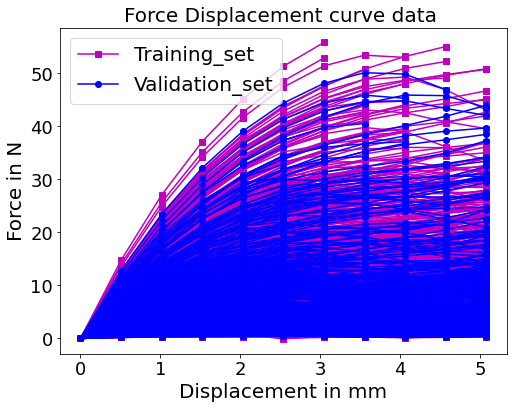

In [100]:
def plotAllFDcurves(inputs_train, targets_train, inputs_test, targets_test, lbls=['', ''], strAdd=''):
    n_total = inputs_train.shape[0] + inputs_test.shape[0]
    # lbls = ["Training_set","Validation_set"]
    # lbls = ["Success","Partial Success"]
    # lbls = ["Data_1","Data_200"]
    mask_start_col = int(inputs_train.shape[1] - targets_train.shape[1])
    print(mask_start_col)
    plt.figure(figsize=(8, 6))
    for i in range(n_total + 1):
        if i < targets_train.shape[0]:
            force_curve = targets_train[i, :].reshape(-1)
            disp_pts = np.linspace(0, 1, len(force_curve))*max_disp_uz_mm
            n_valid_pts = int(inputs_train[i, mask_start_col::].sum())
            if i == 0:
                plt.plot(disp_pts[0:n_valid_pts], force_curve[0:n_valid_pts], 'm-s', label=f'{lbls[0]}')
            else:
                plt.plot(disp_pts[0:n_valid_pts], force_curve[0:n_valid_pts], 'm-s')
                
        else:
            i = i - n_total
            force_curve = targets_test[i, :].reshape(-1)
            disp_pts = np.linspace(0, 1, len(force_curve))*max_disp_uz_mm
            n_valid_pts = int(inputs_test[i, mask_start_col::].sum())
            if i == -1:
                plt.plot(disp_pts[0:n_valid_pts], force_curve[0:n_valid_pts], 'b-o', label=f'{lbls[1]}')
            else:
                plt.plot(disp_pts[0:n_valid_pts], force_curve[0:n_valid_pts], 'b-o')        

    font_size = 20

    # # Labels
    plt.ylabel('Force in N', fontsize=font_size)
    # plt.ylabel('Normalized Force',fontsize=16)
    plt.xlabel('Displacement in mm', fontsize=font_size)
    target = np.concatenate((targets_train, targets_test), axis=0)
    # plt.ylim(None,np.max(target)*1.3)
    plt.xticks(fontsize=font_size - 2)
    plt.yticks(fontsize=font_size - 2)

    titleStr = f'Force Displacement curve data'
    titleStr = f'{titleStr} {strAdd}'
    plt.title(titleStr, fontsize=font_size)
    plt.legend(fontsize=font_size, loc='upper left')
    plt.show()

def plotFDcurves(ax, inputdata, targetdata, lbl, strAdd, colorshape, addLabel=False):
    """
    Plots force-displacement curves for a single dataset on a given figure.

    Args:
        fig (matplotlib.figure.Figure): The figure object to plot on.
        inputdata (NumPy array): The input data array.
        targetdata (NumPy array): The target data array.
        lbl (str): The label for this dataset.
        strAdd (str): A string to add to the title of the plot.
        colorshape (dict): A dictionary specifying the color and marker.
                           Expected keys: 'color' and 'marker'.
                           Example: {'color': 'm', 'marker': 's'}
    """
    n_samples = inputdata.shape[0]
    for i in range(n_samples):
        force_curve = targetdata[i, :].reshape(-1)
        disp_pts = np.linspace(0, 1, len(force_curve)) * max_disp_uz_mm
        n_valid_pts = int(inputdata[i, 2::].sum())
        color = colorshape['color']
        marker = colorshape['marker']
        ax.plot(disp_pts[0:n_valid_pts], force_curve[0:n_valid_pts], marker=marker, linestyle='-', color=color,
                label=lbl if i == 0 else "", linewidth=3, markersize=10)
    
    
    font_size = 20

    if addLabel:
        ax.set_ylabel('Force in N', fontsize=font_size)
        ax.set_xlabel('Displacement in mm', fontsize=font_size)
        ax.set_ylim(None, np.max(targetdata) * 1.8 if targetdata.size > 0 else None)
        titleStr = f'Force Displacement curve data'
        titleStr = f'{titleStr} {strAdd}'
        ax.set_title(titleStr, fontsize=font_size)
        ax.tick_params(labelsize=font_size - 2)

        # ax.legend(fontsize=16, loc='upper left')
    # else:
    #     ax.set_xticklabels([])
    #     ax.set_yticklabels([])
    

    ax.legend(fontsize=font_size, loc='upper left')

    return ax
    
def plotObjSpaceContinuous(x, y, z, savePlt=False, cmap='jet', save_dir=None):
    """
    Create a 2D scatter plot where color represents a continuous value z.

    Parameters:
        x, y : 1D arrays
            Coordinates of the points.
        z : 1D array
            Continuous values associated with each (x, y) point.
        savePlt : bool
            If True, save the plot as an image.
        cmap : str
            Matplotlib colormap name.
    """
    fig, ax = plt.subplots(figsize=(10, 8))

    font_size = 28
    c_values = np.asarray(z, dtype=float) * 100.0
    sc = ax.scatter(x, y, c=c_values, cmap=cmap, s=80, edgecolors='k', linewidth=0.5, vmin=0.0, vmax=100.0)

    ax.set_xlabel('Radii 1', fontsize=font_size)
    ax.set_ylabel('Radii 2', fontsize=font_size)

    # title_str = f"Compression {int(compression_ratio * 100)}%"
    # ax.set_title(title_str, fontsize=font_size)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Success %', fontsize=font_size)
    cbar.set_ticks(np.arange(0, 101, 10))
    cbar.ax.tick_params(labelsize=font_size - 4)

    ax.set_box_aspect(1)
    ax.set_xticks(np.linspace(0.0, 1.0, 6))
    ax.set_yticks(np.linspace(0.0, 1.0, 6))
    ax.tick_params(labelsize=font_size - 2)
               
    if save_dir is not None:
        plt.savefig(save_dir, dpi=300, bbox_inches='tight')

    if savePlt:
        savePath = os.path.realpath(os.path.join(sys.path[0], 'ObjSpacePlotC' + str(int(compression_ratio * 100)) + '_1000.png'))
        plt.savefig(savePath, dpi=300, bbox_inches='tight')
    plt.show()
 
 
############################################################
if n_design_vars == 2:
    from matplotlib.colors import LinearSegmentedColormap
    status_colors = ['#2ca02c', "#ead40c", "#f60909"]
    status_cmap = LinearSegmentedColormap.from_list("status_cmap", ["#f60909", "#ead40c", "#2ca02c"])
    lbls = ["Success", "Partial success", "Failure"]
    
    sv_dir = 'Images/New/ObjSpacePlotC40_1000.png'
    sv_dir = 'Images/New/onlySofAll.png'
    sv_dir = None
    plotObjSpaceContinuous(design_vars[:, 0].reshape(-1), design_vars[:, 1].reshape(-1), sim_status.reshape(-1),
                           savePlt=False, cmap=status_cmap, save_dir=sv_dir)#'RdYlGn')
    
    sv_dir = 'Images/New/ObjSpacePlotC40_1000.png'
    sv_dir = 'Images/New/onlySof1000.png'
    sv_dir = None
    n_valid_steps_train = np.sum(inputs_train[:, 2::], axis=1)
    sim_status_train = n_valid_steps_train / (np.max(n_valid_steps_train)) 
    plotObjSpaceContinuous(inputs_train[:, 0].reshape(-1), inputs_train[:, 1].reshape(-1), sim_status_train.reshape(-1),
                           savePlt=False, cmap=status_cmap, save_dir=sv_dir)#'RdYlGn')
                           
    total_valid_steps = all_inputs[:, 2::].sum(axis=1)
        
    candidate_idx = 350
    full_success_idx = np.where(total_valid_steps == 11)[0]
    full_success_sample = full_success_idx[candidate_idx] if len(full_success_idx) >= candidate_idx else full_success_idx[-1] if len(full_success_idx) > 0 else -1
    
    if include_partial:
        candidate_idx = 90#74
        partial_idx = np.where(total_valid_steps == 8)[0]
        partial_success_sample = partial_idx[candidate_idx] if len(partial_idx) >= candidate_idx else partial_idx[-1] if len(partial_idx) > 0 else -1
    
        candidate_idx = 0
        failure_idx = np.where(total_valid_steps == 1)[0]
        failure_sample = failure_idx[candidate_idx] if len(failure_idx) >= candidate_idx else failure_idx[-1] if len(failure_idx) > 0 else -1
    # print(full_success_sample, partial_success_sample, failure_sample)
    # print(all_targets[failure_sample:failure_sample+1, :])
    
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    ax = plotFDcurves(ax, all_inputs[full_success_sample:full_success_sample+1, :], all_targets[full_success_sample:full_success_sample+1, :], lbls[0], strAdd='', colorshape={'color': status_colors[0], 'marker': 's'}, addLabel=True)
    if include_partial:
        ax = plotFDcurves(ax, all_inputs[partial_success_sample:partial_success_sample+1, :], all_targets[partial_success_sample:partial_success_sample+1, :], lbls[1], strAdd='', colorshape={'color': status_colors[1], 'marker': 'o'}, addLabel=False)
        ax = plotFDcurves(ax, all_inputs[failure_sample:failure_sample+1, :], all_targets[failure_sample:failure_sample+1, :], lbls[2], strAdd='', colorshape={'color': status_colors[2], 'marker': '^'}, addLabel=False)
    # fig.savefig('Images/New/SuccessVfailure.png', dpi=300, bbox_inches='tight')

lbls = ["Training_set", "Validation_set"]
n1, n2 = None, None   # all data
# n1, n2 = 0, 100       # rows 0..99
# n1, n2 = 5, None      # rows 5 to the end
plotAllFDcurves(inputs_train[n1:n2, :], targets_train[n1:n2, :], inputs_test[n1:n2, :], targets_test[n1:n2, :], lbls, strAdd='')

In [101]:
inputs_train_tensor  = torch.tensor(inputs_train, dtype=torch.float32)
targets_train_tensor = torch.tensor(targets_train, dtype=torch.float32)
inputs_test_tensor   = torch.tensor(inputs_test, dtype=torch.float32)
targets_test_tensor  = torch.tensor(targets_test, dtype=torch.float32)

# Create TensorDatasets (separately for train and test)
train_dataset    = TensorDataset(inputs_train_tensor, targets_train_tensor)
test_dataset     = TensorDataset(inputs_test_tensor, targets_test_tensor)

# Create DataLoaders
train_batch_size = int(len(targets_train_tensor) / 1)
test_batch_size  = int(len(targets_test_tensor))
train_loader     = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=False)
test_loader      = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)  # No need to shuffle test data

In [102]:

# n1, n2 = 196, 197

# pred_train, _ = NPmodel.predict_out(inputs_train[n1:n2, :])
# # pred_test, _ = NPmodel.predict_out(inputs_test[n1:n2, :])

# # pred_train = pred_train.reshape((pred_train.shape[0], -1))
# # pred_test = pred_test.reshape((pred_test.shape[0], -1))
# # print(pred_train.shape, pred_test.shape)

# train_inputs_full_mask, test_inputs_full_mask = inputs_train.copy(), inputs_test.copy()
# train_inputs_full_mask[:, n_design_vars::] = 1
# test_inputs_full_mask[:, n_design_vars::] = 1
# # print(test_inputs_full_mask[n1:n2, :])
# plotAllFDcurves(train_inputs_full_mask[n1:n2, :], pred_train, train_inputs_full_mask[n1:n2, :], targets_train[n1:n2, :], strAdd='NN Prediction train')
# # plotAllFDcurves(test_inputs_full_mask[n1:n2, :], pred_test, test_inputs_full_mask[n1:n2, :], targets_test[n1:n2, :], strAdd='NN Prediction test')

Input Var is R and of size 7
Running on GPU
Total number of weights in the model: 7440
Total number of biases in the model: 166


Training: 0it [00:00, ?it/s]

Training: 7it [00:00, 20.90it/s]

Epoch [1/5000], Training loss: 45.7784 , Validation loss: 51.5232,
                 Max absolute difference on Train: 34.9532, and Test: 32.1258


Training: 501it [00:15, 35.60it/s]

...

Epoch [4000/5000], Training loss: 0.6632 , Validation loss: 0.8078,
                 Max absolute difference on Train: 26.2229, and Test: 18.0456


Training: 4504it [02:14, 37.28it/s]

Epoch [4500/5000], Training loss: 0.6966 , Validation loss: 0.7478,
                 Max absolute difference on Train: 21.7460, and Test: 18.8590


Training: 5000it [02:29, 33.52it/s]


Epoch [5000/5000], Training loss: 0.6952 , Validation loss: 0.8857,
                 Max absolute difference on Train: 22.3596, and Test: 18.2178


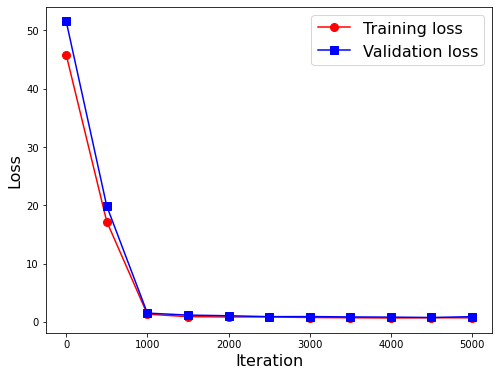

In [103]:
nnSettings = {'inputDim': input_dim,
        'outputDim' : 6, # for F
        'numLayers': 2, 
        'numNeuronsPerLyr': 80,
        'curve':'spline',
        'dropout':0.25, 
        'bottleneck_factor':1.0}

print(f"Input Var is R and of size {input_dim}")
NNmodel = NeuralNet(nnSettings, useCPU=False)
print(f"Total number of weights in the model: {NNmodel.total_weights}")
print(f"Total number of biases in the model: {NNmodel.total_biases}")
NNmodel.train_model(train_loader, test_loader, num_epochs=5000, 
                    prntNum=500,scheduler_type='onecycle') # onecycle, cosine

# NNtraining2var

In [ ]:
print(save_dir)
# Saving the model:
# torch.save(NNmodel, save_dir + 'SurrogateModel.pth')  # Saves the entire model object

C12NN7var/


In [104]:
if not reduce_data:
    avg_mae, avg_rmse,r2,maxV_indexT,minV_indexT = NNmodel.evaluate_NN(train_loader)   # Return both MAE and RMSE
    print("Result on the training set")
    print(f"MAE {avg_mae:.4f} , RMSE {avg_rmse:.4f}, and R_squared {r2:.4f}")
    print(f"Max abs sum error value {maxV_indexT.values.cpu()} ,\n and Index {maxV_indexT.indices.cpu()}\n")
    avg_mae, avg_rmse,r2,maxV_index,minV_index = NNmodel.evaluate_NN(test_loader)   # Return both MAE and RMSE
    print("Result on the test set")
    print(f"MAE {avg_mae:.4f} , RMSE {avg_rmse:.4f}, and R_squared {r2:.4f}")
    print(f"Max abs sum error value {maxV_index.values.cpu()} ,\n and Index {maxV_index.indices.cpu()}\n")


Result on the training set
MAE 0.3195 , RMSE 0.5981, and R_squared 0.9865
Max abs sum error value tensor([3.6681, 3.3651, 3.3136, 3.2054, 3.1009]) ,
 and Index tensor([3014,  195,  285,  551,  244])

Result on the test set
MAE 0.3658 , RMSE 0.6702, and R_squared 0.9849
Max abs sum error value tensor([4.4540, 4.1809, 3.0660, 2.8339, 2.7582]) ,
 and Index tensor([810, 214, 466, 712, 169])




=== Radius pair r1=0.93877551020, r2=0.87755102041 ===
Matching rows in test set: [1]
Row 1:
  radii = [0.93877551 0.87755102]
  test force = [ 0.     14.1929 24.6303 33.0445 39.6413 44.7024 48.5301 51.3792 53.4186
 54.6817 53.7946]
  NN pred    = [ 0.      5.147   8.8801 11.2924 12.9414 13.9201 14.4109 14.5962 14.539
 14.618  14.8966]
2


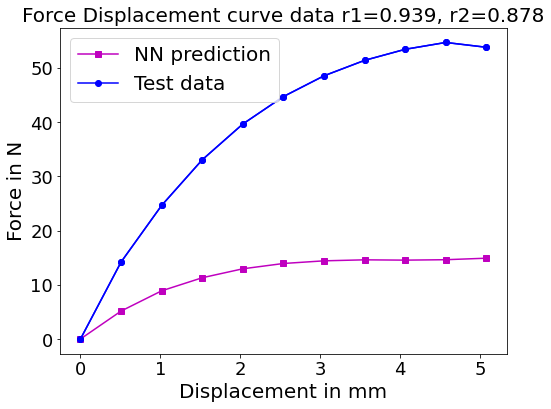


=== Radius pair r1=0.97959183673, r2=0.93877551020 ===
Matching rows in test set: [2]
Row 2:
  radii = [0.97959184 0.93877551]
  test force = [ 0.     15.9933 27.917  37.668  45.4489 51.541  56.2601 59.8942 62.6596
 64.6397 64.268 ]
  NN pred    = [ 0.      5.5259  9.5404 12.1424 13.9255 14.9885 15.5251 15.7287 15.6686
 15.7598 16.0716]
2


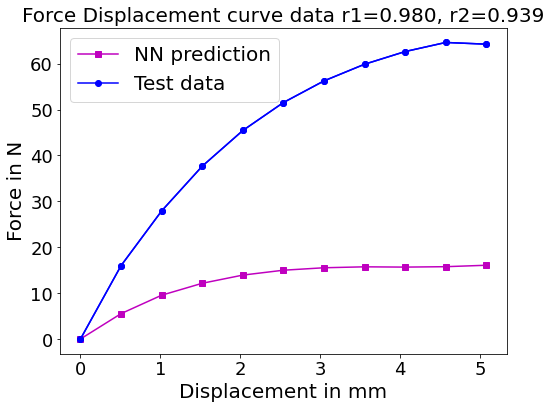

In [69]:
if n_design_vars == 2 and reduce_data:
    def find_rows_for_radius_pair(inputs, radius_pair, tol=1e-6):
        r1_target = float(radius_pair[0])
        r2_target = float(radius_pair[1])
        return np.where((np.abs(inputs[:, 0] - r1_target) <= tol) & (np.abs(inputs[:, 1] - r2_target) <= tol))[0]

    radius_pairs = [
        [0.93877551020408156, 0.87755102040816324],
        [0.97959183673469385, 0.93877551020408156],
    ]

    for radius_pair in radius_pairs:
        match_rows = find_rows_for_radius_pair(inputs_test, radius_pair, tol=1e-6)
        print(f"\n=== Radius pair r1={radius_pair[0]:.11f}, r2={radius_pair[1]:.11f} ===")
        print(f"Matching rows in test set: {match_rows.tolist()}")

        if match_rows.size == 0:
            print("No matching test sample found for this radius pair.")
            continue

        for row_idx in match_rows:
            sample_input = inputs_test[row_idx:row_idx+1, :]
            sample_target = targets_test[row_idx:row_idx+1, :]
            pred_force, _ = NNmodel.predict_out(sample_input)

            print(f"Row {row_idx}:")
            print(f"  radii = {sample_input[0, 0:n_design_vars]}")
            print(f"  test force = {np.round(sample_target.reshape(-1), 4)}")
            print(f"  NN pred    = {np.round(pred_force.reshape(-1), 4)}")

            plotAllFDcurves(
                sample_input, pred_force,
                sample_input, sample_target,
                lbls=['NN prediction', 'Test data'],
                strAdd=f'r1={radius_pair[0]:.3f}, r2={radius_pair[1]:.3f}'
            )

In [13]:
if reduce_data:
    from GPR import GPRegressor
    
    print(f"Input Var is R and of size {input_dim}")
    GPmodel = GPRegressor(nnSettings, useCPU=False)
    
    GPmodel.train_model(train_loader, test_loader, num_epochs=5000, tol=1e-12, prntNum=500)
    avg_mae, avg_rmse, r2, maxV_indexT, minV_indexT = GPmodel.evaluate_NN(train_loader)
    print("Result on the training set")
    print(f"MAE {avg_mae:.4f} , RMSE {avg_rmse:.4f}, and R_squared {r2:.4f}")
    print(f"Max abs sum error value {maxV_indexT.values.cpu()} ,\n and Index {maxV_indexT.indices.cpu()}\n")
    # avg_mae, avg_rmse, r2, maxV_index, minV_index = GPmodel.evaluate_NN(test_loader)
    # print("Result on the test set")
    # print(f"MAE {avg_mae:.4f} , RMSE {avg_rmse:.4f}, and R_squared {r2:.4f}")
    # print(f"Max abs sum error value {maxV_index.values.cpu()} ,\n and Index {maxV_index.indices.cpu()}\n")
    
    
    if n_design_vars == 2:
       
        radius_pairs = [
            [0.93877551020408156, 0.87755102040816324],
            [0.97959183673469385, 0.93877551020408156],
        ]
    
        for radius_pair in radius_pairs:
            match_rows = find_rows_for_radius_pair(inputs_test, radius_pair, tol=1e-6)
            print(f"\n=== Radius pair r1={radius_pair[0]:.11f}, r2={radius_pair[1]:.11f} ===")
            print(f"Matching rows in test set: {match_rows.tolist()}")
    
            if match_rows.size == 0:
                print("No matching test sample found for this radius pair.")
                continue
    
            for row_idx in match_rows:
                sample_input = inputs_test[row_idx:row_idx+1, :]
                sample_target = targets_test[row_idx:row_idx+1, :]
                pred_force, _ = GPmodel.predict_out(sample_input)
    
                print(f"Row {row_idx}:")
                print(f"  radii = {sample_input[0, 0:n_design_vars]}")
                print(f"  test force = {np.round(sample_target.reshape(-1), 4)}")
                print(f"  NN pred    = {np.round(pred_force.reshape(-1), 4)}")
    
                plotAllFDcurves(
                    sample_input, pred_force,
                    sample_input, sample_target,
                    lbls=['NN prediction', 'Test data'],
                    strAdd=f'r1={radius_pair[0]:.3f}, r2={radius_pair[1]:.3f}'
                )
    
    # xglobal = objlandscape(GPmodel.predict_out)
    # objlandscapeMSE(GPmodel.predict_out, design_vars_converged, forces_converged)

In [14]:
if reduce_data:
    from RBF import RBFRegressor
    
    print(f"Input Var is R and of size {input_dim}")
    RBFmodel = RBFRegressor(nnSettings, useCPU=False)
    
    RBFmodel.train_model(train_loader, test_loader, num_epochs=5000, tol=1e-12, prntNum=500)
    avg_mae, avg_rmse, r2, maxV_indexT, minV_indexT = RBFmodel.evaluate_NN(train_loader)
    print("Result on the training set")
    print(f"MAE {avg_mae:.4f} , RMSE {avg_rmse:.4f}, and R_squared {r2:.4f}")
    print(f"Max abs sum error value {maxV_indexT.values.cpu()} ,\n and Index {maxV_indexT.indices.cpu()}\n")
    # avg_mae, avg_rmse, r2, maxV_index, minV_index = RBFmodel.evaluate_NN(test_loader)
    # print("Result on the test set")
    # print(f"MAE {avg_mae:.4f} , RMSE {avg_rmse:.4f}, and R_squared {r2:.4f}")
    # print(f"Max abs sum error value {maxV_index.values.cpu()} ,\n and Index {maxV_index.indices.cpu()}\n")
    
    
    if n_design_vars == 2:
       
        radius_pairs = [
            [0.93877551020408156, 0.87755102040816324],
            [0.97959183673469385, 0.93877551020408156],
        ]
    
        for radius_pair in radius_pairs:
            match_rows = find_rows_for_radius_pair(inputs_test, radius_pair, tol=1e-6)
            print(f"\n=== Radius pair r1={radius_pair[0]:.11f}, r2={radius_pair[1]:.11f} ===")
            print(f"Matching rows in test set: {match_rows.tolist()}")
    
            if match_rows.size == 0:
                print("No matching test sample found for this radius pair.")
                continue
    
            for row_idx in match_rows:
                sample_input = inputs_test[row_idx:row_idx+1, :]
                sample_target = targets_test[row_idx:row_idx+1, :]
                pred_force, _ = RBFmodel.predict_out(sample_input)
    
                print(f"Row {row_idx}:")
                print(f"  radii = {sample_input[0, 0:n_design_vars]}")
                print(f"  test force = {np.round(sample_target.reshape(-1), 4)}")
                print(f"  NN pred    = {np.round(pred_force.reshape(-1), 4)}")
    
                plotAllFDcurves(
                    sample_input, pred_force,
                    sample_input, sample_target,
                    lbls=['NN prediction', 'Test data'],
                    strAdd=f'r1={radius_pair[0]:.3f}, r2={radius_pair[1]:.3f}'
                )
    
    # # xglobal = objlandscape(RBFmodel.predict_out)
    # # objlandscapeMSE(RBFmodel.predict_out, design_vars_converged, forces_converged)

7


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


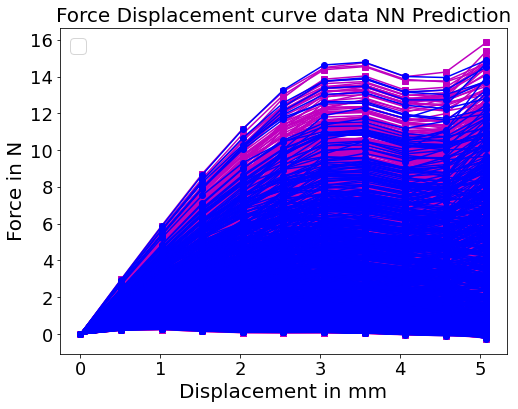

In [84]:
pred_train, _ = NNmodel.predict_out(inputs_train)
pred_test, _ = NNmodel.predict_out(inputs_test)
train_inputs_full_mask, test_inputs_full_mask = inputs_train.copy(), inputs_test.copy()
train_inputs_full_mask[:, n_design_vars::] = 1
test_inputs_full_mask[:, n_design_vars::] = 1
plotAllFDcurves(train_inputs_full_mask, pred_train, test_inputs_full_mask, pred_test, strAdd='NN Prediction')

In [35]:
def plotNNFDcurve(inputs, target, arrayN, titleStrAdd, pltCP=False, savePath=None):
    print(inputs.shape)
    for start_idx in arrayN:
        end_idx = start_idx + 1
        sample_input = inputs[start_idx:end_idx, :]
        print(sample_input, inputs[start_idx, :])
        eval_disp_pts = np.linspace(0, 1, 2 * len(sample_input[0, 2::]) - 1)
        pred_force, control_points = NNmodel.predict_out(sample_input, eval_disp_pts)
        actual_force = target[start_idx:end_idx, :].reshape(-1)
        print(f"Rad values: {sample_input},\n")
    
        plt.figure(figsize=(8, 6))
        disp_pts = np.linspace(0, 1, len(actual_force)) * max_disp_uz_mm
        n_valid_pts = int(sample_input[0, -len(actual_force)::].sum())
        plt.plot(disp_pts[0:n_valid_pts], actual_force[0:n_valid_pts], 'r--^', label='Abaqus data', markersize=15, linewidth=3)
        # plt.plot(eval_disp_pts, pred_force.reshape(-1), 'b--h', label='Surrogate model prediction - 21 points', linewidth=3, markersize=8)
        eval_disp_pts = np.linspace(0, 1, len(sample_input[0, 2::]))
        pred_force, control_points = NNmodel.predict_out(sample_input, eval_disp_pts)
        plt.plot(eval_disp_pts*max_disp_uz_mm, pred_force.reshape(-1), 'g--o', label='Surrogate model prediction', linewidth=3, markersize=10)
        
        if pltCP:
            control_points = control_points.reshape(-1)
            n_cp = len(control_points)
            spline_degree = 2  # hard coded to degree 2
            knot_spans = np.linspace(0, 1, n_cp - spline_degree + 1)
            cp_disp_pts = np.linspace(0, 1, n_cp - spline_degree + 2)
            cp_disp_pts[1:-1] = knot_spans[:-1] + np.diff(knot_spans) / 2
            plt.plot(cp_disp_pts*max_disp_uz_mm, control_points, 'm--s', label='NN predicted B-Spline control points', markersize=10)      
        
        font_size = 20
           
        # # Labels
        plt.ylabel('Force in N', fontsize=font_size)
        plt.xlabel('Displacement in mm', fontsize=font_size)
        plt.xticks(fontsize=font_size - 2)
        plt.yticks(fontsize=font_size - 2)
        
        y_axis_max = np.max(np.concatenate((actual_force.reshape(-1), pred_force.reshape(-1)))) * 2.0
        plt.ylim([None, y_axis_max])
        
        # titleStr = f'Force Displacement curve on {titleStrAdd} data {start_idx}\n abs force diff = ...'
        # plt.title(titleStr, fontsize=18)
        plt.legend(fontsize=font_size, loc='upper left')
        if savePath is not None:
           plt.savefig(savePath, dpi=300, bbox_inches='tight')

        plt.show()


batch_inputs_list = []
batch_targets_list = []

for inputs, targets in train_loader:
    batch_inputs_list.append(inputs)
    batch_targets_list.append(targets)
    
inputs_train = torch.cat(batch_inputs_list, dim=0).detach().cpu().numpy()
targets_train = torch.cat(batch_targets_list, dim=0).detach().cpu().numpy()
    
print("Number of train data", inputs_train.shape)
top_err_train_idx = maxV_indexT.indices.cpu().numpy()

# plotNNFDcurve(inputs_train, targets_train, maxV_indexT.indices.cpu().numpy(), 'trained', pltCP=True)

# plotNNFDcurve(inputs_train, targets_train, minV_indexT.indices.cpu().numpy(), 'trained')

Number of train data (1997, 13)


In [28]:
batch_inputs_list = []
batch_targets_list = []

for inputs, targets in test_loader:
    batch_inputs_list.append(inputs)
    batch_targets_list.append(targets)
    
inputs_test = torch.cat(batch_inputs_list, dim=0).detach().cpu().numpy()
targets_test = torch.cat(batch_targets_list, dim=0).detach().cpu().numpy()

print("Number of test data", inputs_test.shape)
# plotNNFDcurve(inputs_test, targets_test, maxV_index.indices.cpu().numpy(), 'validation')
# plotNNFDcurve(inputs_test, targets_test, minV_index.indices.cpu().numpy(), 'validation')

Number of test data (501, 13)


In [29]:
random_array = np.sort(np.random.randint(0,len(inputs_test[:,0]),size=5))

In [19]:

# plotNNFDcurve(inputs_train, targets_train, random_array, 'trained random', pltCP=True)
# plotNNFDcurve(inputs_test, targets_test, random_array, 'validation random', pltCP=True)

[   3    5   24   28   53   70   98   99  100  103  122  149  152  160
  183  197  262  268  275  315  322  339  343  379  385  401  407  410
  413  429  459  465  471  475  481  483  529  532  534  544  593  606
  612  625  635  638  639  640  651  654  655  661  674  675  682  685
  686  690  708  714  725  728  738  751  756  772  787  820  826  870
  887  889  919  923  925  941  965  971  984 1012 1014 1018 1023 1046
 1052 1054 1065 1077 1088 1136 1141 1144 1146 1148 1155 1160 1175 1200
 1212 1236 1243 1251 1257 1262 1267 1269 1277 1278 1281 1283 1297 1298
 1304 1313 1316 1330]
idx: 0
(1, 13)
[[0.26530612 0.4489796  1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.        ]] [0.26530612 0.4489796  1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.        ]
Rad values: [[0.26530612 0.4489796  1.         1.         1.         1.
  1.         1.         1.         1.         1.         

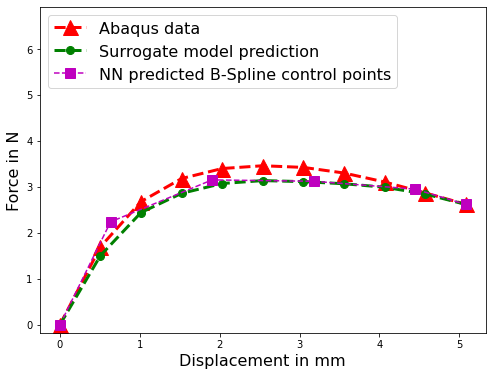

In [30]:
#This is to show the CP and surrogate model and data
if n_design_vars == 2:
    max_force_per_sample = np.max(targets_train, axis=1)
     
    filtered_train_inputs = inputs_train[(max_force_per_sample > 2.0), :]
    filtered_train_targets = targets_train[(max_force_per_sample > 2.0), :]
    
    total_valid_steps = filtered_train_inputs[:, 2::].sum(axis=1)
    full_success_indices = np.where(total_valid_steps == 11)[0]
    print(full_success_indices)
    for i in range(len(full_success_indices)*0+1):
        print("idx:", i)
        sample_idx = full_success_indices[i]  # 2,12 is close used for part1
        plotNNFDcurve(filtered_train_inputs[sample_idx, :].reshape(1, -1), filtered_train_targets[sample_idx, :].reshape(1, -1),
                      np.array([0]), 'trained', pltCP=True, savePath='Images/New/SurrNdata2.png')

-- ()
(1, 13)
[[0.5102041 0.2244898 1.        1.        1.        1.        1.
  1.        1.        1.        1.        1.        1.       ]] [0.5102041 0.2244898 1.        1.        1.        1.        1.
 1.        1.        1.        1.        1.        1.       ]
Rad values: [[0.5102041 0.2244898 1.        1.        1.        1.        1.
  1.        1.        1.        1.        1.        1.       ]],



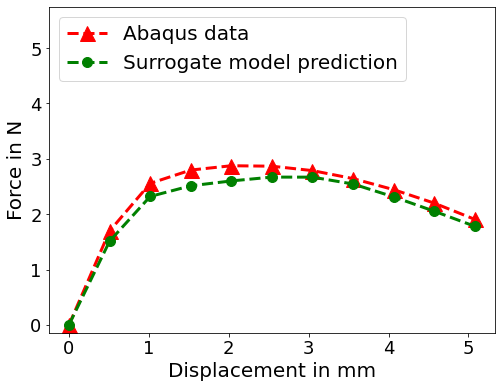

-- ()
(1, 13)
[[0.3265306 0.6530612 1.        1.        1.        1.        1.
  1.        1.        0.        0.        0.        0.       ]] [0.3265306 0.6530612 1.        1.        1.        1.        1.
 1.        1.        0.        0.        0.        0.       ]
Rad values: [[0.3265306 0.6530612 1.        1.        1.        1.        1.
  1.        1.        0.        0.        0.        0.       ]],



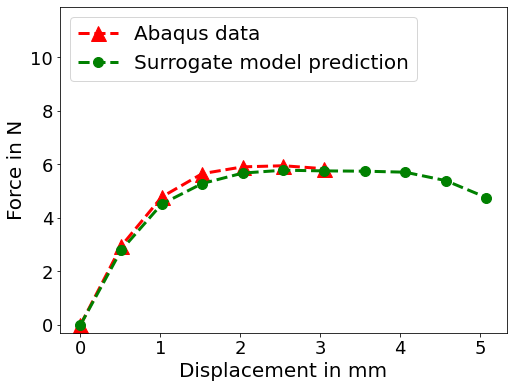

-- ()
(1, 13)
[[0.2244898  0.95918367 1.         1.         1.         1.
  0.         0.         0.         0.         0.         0.
  0.        ]] [0.2244898  0.95918367 1.         1.         1.         1.
 0.         0.         0.         0.         0.         0.
 0.        ]
Rad values: [[0.2244898  0.95918367 1.         1.         1.         1.
  0.         0.         0.         0.         0.         0.
  0.        ]],



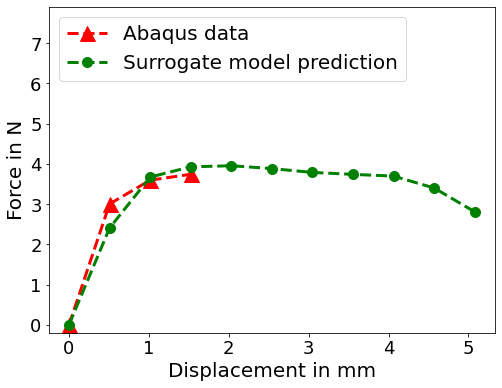

In [45]:
#This is to show surrogate model and data on test for full and partial success
if n_design_vars == 2:
    main_dir = 'Images/New/'
    max_force_per_sample = np.max(targets_test, axis=1)
    
    filtered_test_inputs = inputs_test[(max_force_per_sample > 1.5), :]
    filtered_test_targets = targets_test[(max_force_per_sample > 1.5), :]
    
    total_valid_steps = filtered_test_inputs[:, 2::].sum(axis=1)
    sample_idx = np.where(total_valid_steps == 11)[0][5]  # 5
    print("--", sample_idx.shape)
    plotNNFDcurve(filtered_test_inputs[sample_idx, :].reshape(1, -1), filtered_test_targets[sample_idx, :].reshape(1, -1),
                    np.array([0]), 'trained', pltCP=False, savePath=main_dir + 'SurrValidatePredFull.png')
                    
    # find the half success 
    sample_idx = np.where((total_valid_steps == 7) & (filtered_test_targets[:, 6] >= 5.0) & (filtered_test_targets[:, 6] <= 6.0))[0][1]  # 1
    print("--", sample_idx.shape)
    plotNNFDcurve(filtered_test_inputs[sample_idx, :].reshape(1, -1), filtered_test_targets[sample_idx, :].reshape(1, -1),
                    np.array([0]), 'trained', pltCP=False, savePath=main_dir + 'SurrValidatePredPartial.png')
    
    ## special for failure
    max_force_per_sample = np.max(all_targets, axis=1)
    
    filtered_test_inputs = all_inputs[(max_force_per_sample > 1.5), :]
    filtered_test_targets = all_targets[(max_force_per_sample > 1.5), :]
    
    total_valid_steps = filtered_test_inputs[:, 2::].sum(axis=1)
    
    # find the failure  
    sample_idx = np.where((total_valid_steps == 4))[0][5]  # 10
    print("--", sample_idx.shape)
    plotNNFDcurve(filtered_test_inputs[sample_idx, :].reshape(1, -1), filtered_test_targets[sample_idx, :].reshape(1, -1),
    np.array([0]), 'trained', pltCP=False, savePath=main_dir + 'SurrValidatePredFailure.png')

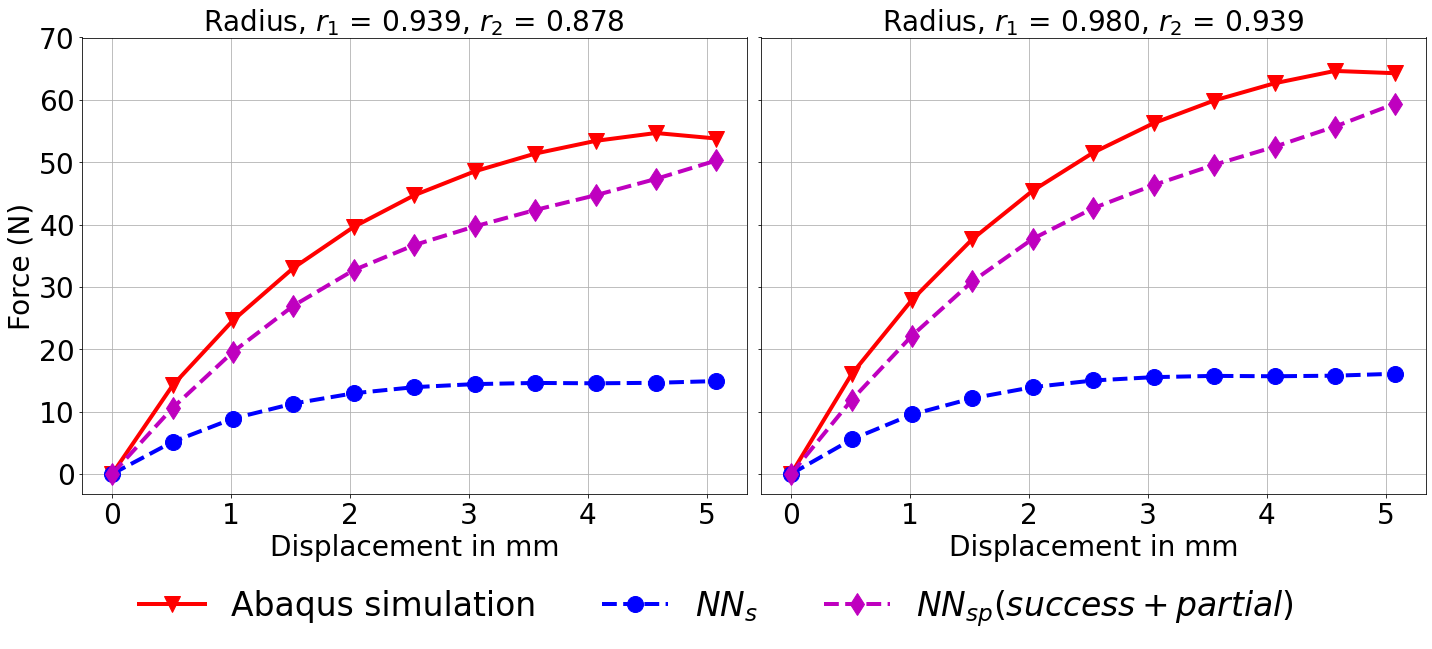

In [71]:
if reduce_data:
    import matplotlib.pyplot as plt
    import numpy as np
    
    radius_cases = [
        np.array([0.93877551, 0.87755102, 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
        np.array([0.97959184, 0.93877551, 1., 1., 1., 1., 1., 1., 1., 1., 1.])
    ]
    
    abaqus_forces = [
        np.array([
            0.0, 14.1929, 24.6303, 33.0445, 39.6413,
            44.7024, 48.5301, 51.3792, 53.4186, 54.6817, 53.7946
        ]),
        np.array([
            0.0, 15.9933, 27.9170, 37.6680, 45.4489,
            51.5410, 56.2601, 59.8942, 62.6596, 64.6397, 64.2680
        ]),
    ]
    
    nn_success_preds = [
        np.array([
            0.0, 5.1470, 8.8801, 11.2924, 12.9414,
            13.9201, 14.4109, 14.5962, 14.5390, 14.6180, 14.8966
        ]),
        np.array([
            0.0, 5.5259, 9.5404, 12.1424, 13.9255,
            14.9885, 15.5251, 15.7287, 15.6686, 15.7598, 16.0716
        ]),
    ]
    
    nn_partial_preds = [
        np.array([
            0.0, 10.5850, 19.5850, 26.9856, 32.6993,
            36.7115, 39.6971, 42.3308, 44.6989, 47.3196, 50.2792
        ]),
        np.array([
            0.0, 11.8599, 22.1705, 30.8847, 37.7190,
            42.6263, 46.3369, 49.5813, 52.4753, 55.7144, 59.4143
        ]),
    ]
    
    gpr_preds = [
        np.array([
            0.0, 0.0393, 0.0640, 0.0898, 0.1016,
            0.1026, 0.1006, 0.1100, 0.1166, 0.1244, 0.1494
        ]),
        np.array([
            0.0, 0.0080, 0.0130, 0.0182, 0.0204,
            0.0205, 0.0202, 0.0227, 0.0245, 0.0265, 0.0315
        ]),
    ]
    
    rbf_preds = [
        np.array([
            0.0, 7.0342, 11.8044, 14.7306, 16.6420,
            17.8878, 18.6234, 18.8042, 18.5304, 18.3948, 18.3403
        ]),
        np.array([
            0.0, 7.4258, 12.4323, 15.4911, 17.4900,
            18.7945, 19.5653, 19.7514, 19.4543, 19.3036, 19.2334
        ]),
    ]

    old_res = False
    if old_res == True:
        radius_cases = [
            np.array([0.89795918, 0.89795918, 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
            np.array([0.97959184, 0.97959184, 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
        ]
        
        abaqus_forces = [
            np.array([0., 3.49913239, 6.78165674, 9.82433987, 12.60247803, 15.08982849,
                      17.25162125, 19.06362915, 20.49136162, 21.50000763, 21.98828316]),
            np.array([0., 4.06288433, 7.88350201, 11.43645668, 14.69516087, 17.63195038,
                      20.21074104, 22.40847206, 24.19458199, 25.53834152, 26.4025135])
        ]
        
        nn_success_preds = [
            np.array([0., 2.814615, 5.6688924, 8.42327, 10.240379, 10.980657,
                      11.087289, 11.003459, 10.565243, 8.78907, 5.511013]),
            np.array([0., 3.1269095, 6.3098407, 9.391575, 11.428801, 12.264299,
                      12.391927, 12.305541, 11.821635, 9.8391695, 6.1746373])
        ]
        
         
         
        gpr_preds = [
            np.array([0., 1.00560034, 1.85858541, 3.05295239, 4.17141815, 2.69654166,
                      5.20237712, 5.23500212, 5.26441311, 5.57527124, 4.25568379]),
            np.array([0., 0.33999367, 0.62654862, 1.08090998, 1.44871907, 0.69993617,
                      1.76976068, 1.82172284, 1.91373606, 2.14654206, 1.70552334])
        ]
        
        rbf_preds = [
            np.array([0., 2.78694594, 5.07441922, 7.18232406, 9.17503865, 11.28852665,
                      12.50427699, 12.20426365, 11.71010745, 10.53381022, 6.65817665]),
            np.array([0., 2.96327953, 5.30841502, 7.46529712, 9.53048384, 11.7966731,
                      13.15217872, 12.8225836, 12.27776061, 11.00910748, 6.95985359])
        ]
        
        nn_partial_preds = [
            np.array([0., 3.1774452, 6.3009367, 9.32108, 11.941513, 14.112841,
                      15.7704935, 16.849903, 17.243656, 16.307259, 13.933296]),
            np.array([0., 3.5371728, 7.034534, 10.442919, 13.467348, 16.058659,
                      18.089546, 19.432709, 19.973156, 19.020966, 16.461147])
        ]
    
    plt_curvs = [1, 2, 3]
    plt_curvs = [3, 4]
    # --- Plotting ---
    labels = [
        r"Abaqus simulation",
        r"RBF",
        r"GPR",
        r"$NN_{s}$",
        r"$NN_{sp} (success+partial)$"
    ]
    colors = ["r", "b", "g", "y", "m"]
    linestyles = ["-", "--", "--", "--", "--"]
    markerShapes = ['v', 'o', '>', 's', 'd']
    font_size = 28
    marker_size = 16
    line_width = 4
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
    disp_norm_pts = np.linspace(0, 1, 11)*max_disp_uz_mm
    for i, ax in enumerate(axes):
        ax.plot(disp_norm_pts, abaqus_forces[i], colors[0] + linestyles[0] + markerShapes[0],
            linewidth=line_width, markersize=marker_size)
        if 1 in plt_curvs:    
            ax.plot(disp_norm_pts, rbf_preds[i], colors[3] + linestyles[3] + markerShapes[3],
                    linewidth=line_width, markersize=marker_size)
        if 2 in plt_curvs:
            ax.plot(disp_norm_pts, gpr_preds[i], colors[2] + linestyles[2] + markerShapes[2],
                    linewidth=line_width, markersize=marker_size)
        if 3 in plt_curvs:
            ax.plot(disp_norm_pts, nn_success_preds[i], colors[1] + linestyles[1] + markerShapes[1],
                    linewidth=line_width, markersize=marker_size)
        if 4 in plt_curvs:
            ax.plot(disp_norm_pts, nn_partial_preds[i], colors[4] + linestyles[4] + markerShapes[4],
                    linewidth=line_width, markersize=marker_size)
    
        ax.set_title(f"Radius, $r_1$ = {radius_cases[i][0]:.3f}, $r_2$ = {radius_cases[i][1]:.3f}", fontsize=font_size)
        ax.set_xlabel("Displacement in mm", fontsize=font_size)
        if i == 0:
            ax.set_ylabel("Force (N)", fontsize=font_size)
    
        ax.tick_params(axis='both', labelsize=font_size)
        
        ax.grid(True)
        
    plt_curvs = [0]+plt_curvs
    active_labels = [labels[i] for i in plt_curvs]
    fig.legend(
        active_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=len(labels),
        fontsize=font_size + 5,
        frameon=False
    )
    
    ax.set_ylim([None, 70.])
    plt.tight_layout()
    if 1 in plt_curvs:
        plt.savefig("Images/New/FDcompare.png", dpi=300, bbox_inches='tight')
    if 4 in plt_curvs:
        plt.savefig("Images/New/FDcompare_NN.png", dpi=300, bbox_inches='tight')
    plt.show()